**Task 1: Data Cleaning & Visualization**

/tmp/ipykernel_5162/4078265179.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=df, palette='Set2')


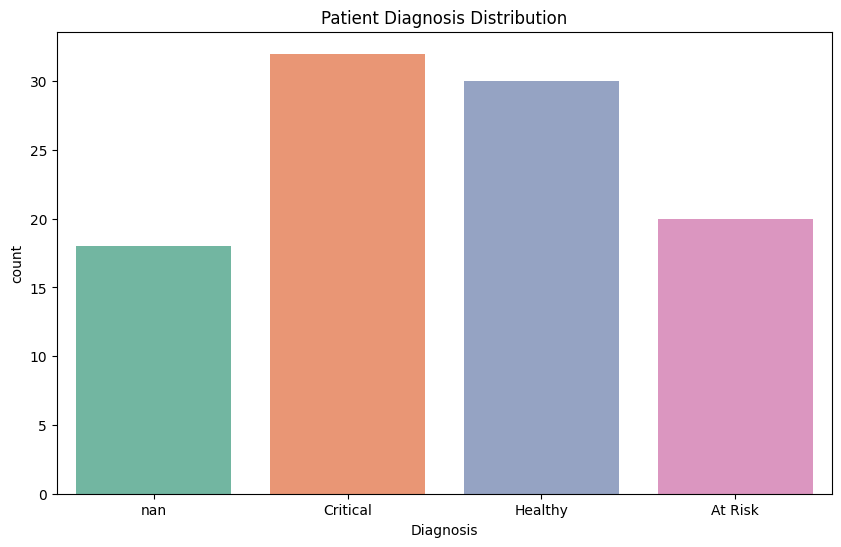

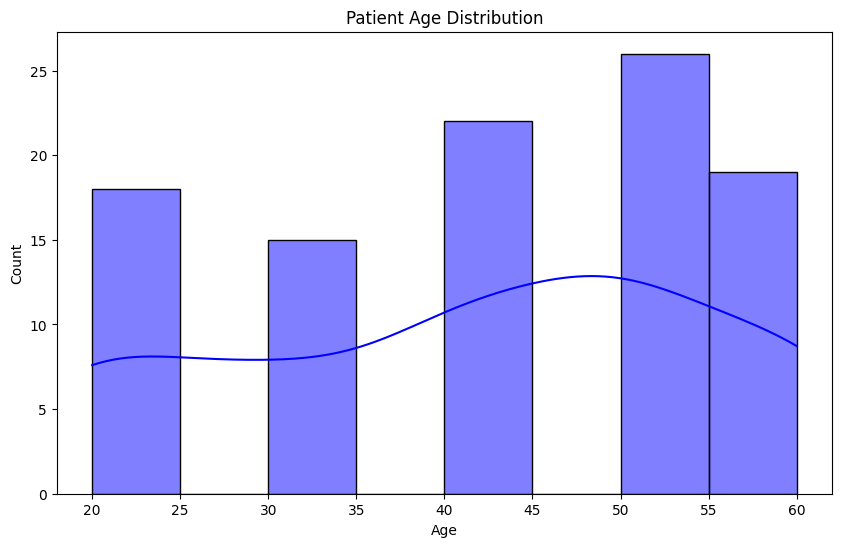

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup Data
np.random.seed(7)
data = {
    'PatientID': range(1, 101),
    'Age': np.random.choice([20, 30, 40, 50, 60, np.nan], 100),
    'Cholesterol': np.random.uniform(150, 300, 100),
    'BloodPressure': np.random.choice([110, 120, 130, 140, np.nan], 100),
    'Diagnosis': np.random.choice(['Healthy', 'At Risk', 'Critical', np.nan], 100)
}
df = pd.DataFrame(data)

# Cleaning
df.loc[0:8, 'Cholesterol'] = np.nan
df = pd.concat([df, df.iloc[[0, 1]]]) # Add duplicates
df = df.drop_duplicates() # Remove duplicates
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].median())
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].mode()[0])
df['Diagnosis'] = df['Diagnosis'].fillna('Unknown')

# Visuals
plt.figure(figsize=(10,6))
sns.countplot(x='Diagnosis', data=df, palette='Set2')
plt.title('Patient Diagnosis Distribution')
plt.savefig('task1_dist.png')
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(df['Age'], kde=True, color='blue')
plt.title('Patient Age Distribution')
plt.savefig('task1_age.png')
plt.show()

**Task 2: Predictive Modeling**

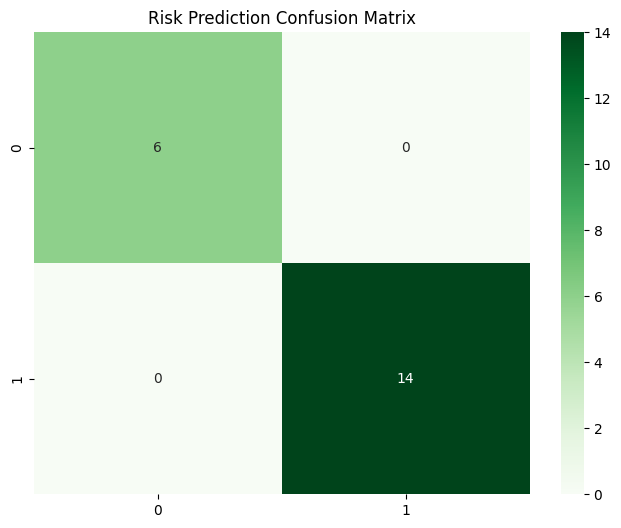

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Target: 1 if Cholesterol > 220 (High Risk), else 0
df['Target'] = (df['Cholesterol'] > 220).astype(int)
X = df[['Age', 'Cholesterol']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap='Greens', fmt='d')
plt.title('Risk Prediction Confusion Matrix')
plt.savefig('task2_ml.png')
plt.show()

**Task 3: Exploratory Data Analysis (EDA)**

        PatientID         Age  Cholesterol  BloodPressure      Target
count  100.000000  100.000000   100.000000     100.000000  100.000000
mean    50.500000   41.460674   225.742727     128.300000    0.600000
std     29.011492   13.747401    38.434372      11.896439    0.492366
min      1.000000   20.000000   151.768618     110.000000    0.000000
25%     25.750000   30.000000   200.543254     120.000000    0.000000
50%     50.500000   41.460674   224.687867     130.000000    1.000000
75%     75.250000   50.000000   252.417359     140.000000    1.000000
max    100.000000   60.000000   299.894559     140.000000    1.000000


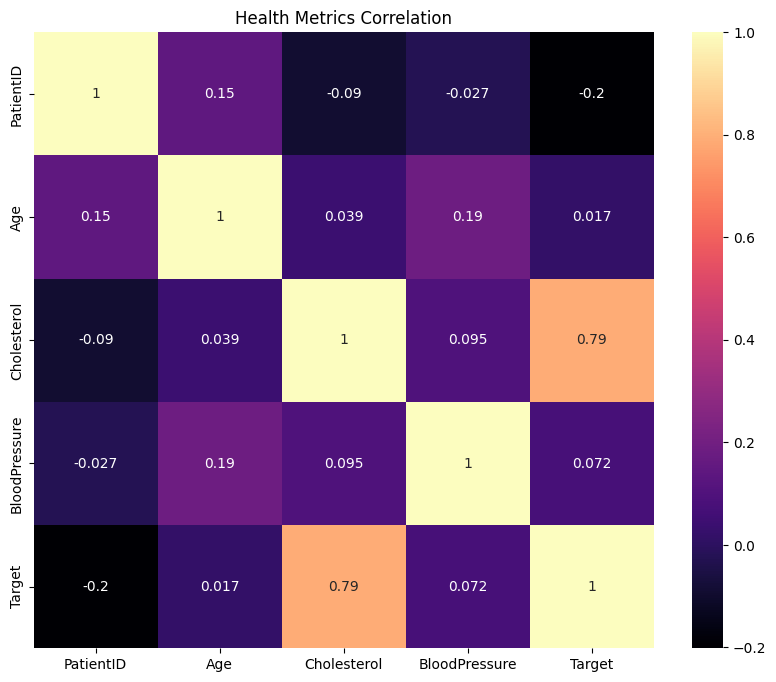

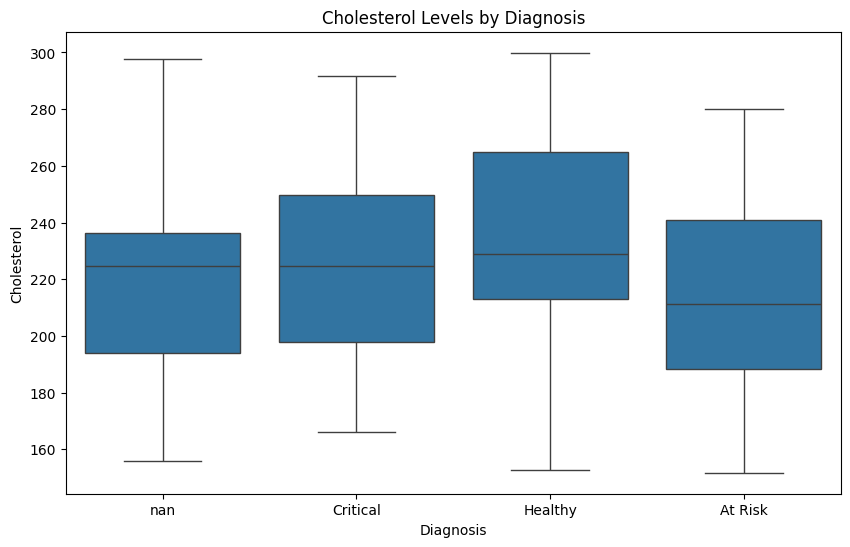

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Statistical Summary
print(df.describe())

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='magma')
plt.title('Health Metrics Correlation')
plt.savefig('task3_corr.png')
plt.show()

# Boxplot for Outliers/Distribution
plt.figure(figsize=(10,6))
sns.boxplot(x='Diagnosis', y='Cholesterol', data=df)
plt.title('Cholesterol Levels by Diagnosis')
plt.savefig('task3_box.png')
plt.show()

**Task 4: Real-world Domain Project (Health Finance)**

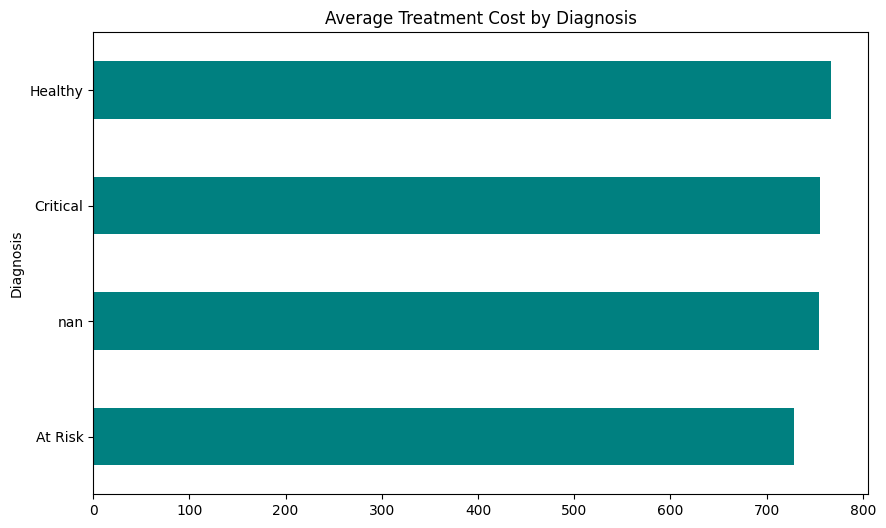

In [5]:
import matplotlib.pyplot as plt

df_health = df.copy()
# Formula: Cost = (Cholesterol * 1.5) + (Age * 10)
df_health['Treatment_Cost'] = df_health['Cholesterol'] * 1.5 + (df_health['Age'] * 10)

# Group by Diagnosis
cost_analysis = df_health.groupby('Diagnosis')['Treatment_Cost'].mean().sort_values()

plt.figure(figsize=(10,6))
cost_analysis.plot(kind='barh', color='teal')
plt.title('Average Treatment Cost by Diagnosis')
plt.savefig('task4_finance.png')
plt.show()